# Neural Networks — Cirrhosis Risk Diagnosis
### Discovery-to-Action (DTA) Strategy

**Author:** Ismail Muhammad (Aisinwaka)
**Program:** 3MTT — AI & Machine Learning

**Role:** Health-tech data scientist building a neural network to predict cirrhosis
patient outcomes from clinical trial data, using Python, pandas, and TensorFlow/Keras.

This notebook follows the Discovery-to-Action (DTA) framework: clean and prepare clinical
data under strict rules, build and train a simple deep learning model, and critically
evaluate its performance through a **clinical lens** — where the cost of a missed
diagnosis is very different from the cost of a false alarm.


## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")


I0000 00:00:1783054007.957011     578 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783054007.957781     578 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783054008.021666     578 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783054009.539830     578 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783054009.540476     578 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## 1. Discovery Phase — Data Preparation

### 1.1 Load the dataset and remove all rows containing "NA" values

The dataset comes from a Mayo Clinic primary biliary cirrhosis (PBC) trial. Not every
patient underwent the full lab panel — a subset only has basic measurements, so several
lab columns (Cholesterol, Copper, Alk_Phos, SGOT, Tryglicerides) contain `"NA"` entries.
Per the project's strict cleaning rule, we drop any row with a missing value rather than
imputing, to keep every training example fully clinically-observed.


In [2]:
df = pd.read_csv('cirrhosis.csv', na_values='NA')
print(f"Raw shape: {df.shape}")

df = df.dropna().reset_index(drop=True)
print(f"Shape after dropping rows with NA: {df.shape}")

df.head()


Raw shape: (418, 20)
Shape after dropping rows with NA: (303, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,2732,D,Placebo,25395,F,Y,Y,N,Y,0.40,264.0,3.19,216.0,1198.0,11.2,166.0,273.0,11.1,4.0
1,3,2064,D,D-penicillamine,14990,F,N,N,Y,N,2.45,209.0,2.53,60.0,1757.0,145.0,229.0,450.0,11.8,4.0
2,4,4471,C,D-penicillamine,21564,F,N,Y,N,N,2.05,544.0,2.90,114.0,3349.0,60.3,74.0,241.0,10.8,3.0
3,5,1565,C,D-penicillamine,20884,F,N,N,N,N,1.87,375.0,3.46,100.0,2930.0,155.8,170.0,293.0,10.8,2.0
4,6,1318,C,D-penicillamine,15865,F,Y,N,N,N,1.39,262.0,3.55,17.0,-1588.0,74.2,201.0,353.0,10.9,2.0


### 1.2 Transform the `Status` target column

`Status` records the trial outcome: `D` (death), `C` (censored — alive at last contact),
or `CL` (censored due to liver transplant). Per the project spec, we encode this as a
binary target: **`D` → 0 (Death)**, **`C`/`CL` → 1 (No death recorded)**.


In [3]:
print("Raw Status distribution:")
print(df['Status'].value_counts())

df['Status'] = df['Status'].apply(lambda s: 0 if s == 'D' else 1)

print("\nEncoded target distribution (0=Death, 1=No death recorded):")
print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True).round(3))


Raw Status distribution:
Status
C     209
D      77
CL     17
Name: count, dtype: int64

Encoded target distribution (0=Death, 1=No death recorded):
Status
1    226
0     77
Name: count, dtype: int64
Status
1    0.746
0    0.254
Name: proportion, dtype: float64


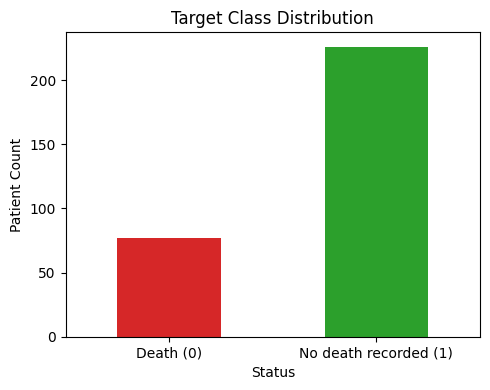

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
df['Status'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#d62728', '#2ca02c']
)
ax.set_xticklabels(['Death (0)', 'No death recorded (1)'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Patient Count')
plt.tight_layout()
plt.show()


### 1.3 Drop non-predictive columns

`ID` is a row identifier (no clinical signal). `N_Days` (follow-up duration) and `Drug`
are dropped as instructed to prevent leakage and noise — `N_Days` is intertwined with how
`Status` was recorded (a patient followed for a very short time who died vs. one followed
for years and censored), which would leak outcome-adjacent information rather than
reflect a patient's clinical risk at baseline.


In [5]:
y = df['Status']
X = df.drop(columns=['ID', 'N_Days', 'Status', 'Drug'])

print(f"Remaining feature columns ({X.shape[1]}):")
print(list(X.columns))


Remaining feature columns (16):


['Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


### 1.4 Manually encode binary string features, then `pd.get_dummies()` for the rest

- `Sex`: F → 1, M → 0
- `Ascites`, `Hepatomegaly`, `Spiders`: Y → 1, N → 0
- `Edema` has **three** categories (N / S / Y — no edema / edema without diuretic
  treatment / edema despite treatment), so it isn't a clean binary — we one-hot encode it
  with `pd.get_dummies()` instead of forcing it into a Y/N map.


In [6]:
binary_maps = {
    'Sex': {'F': 1, 'M': 0},
    'Ascites': {'Y': 1, 'N': 0},
    'Hepatomegaly': {'Y': 1, 'N': 0},
    'Spiders': {'Y': 1, 'N': 0},
}
for col, mapping in binary_maps.items():
    X[col] = X[col].map(mapping)

X = pd.get_dummies(X, columns=['Edema'], drop_first=False)

print(f"Feature matrix shape after encoding: {X.shape}")
X.head()


Feature matrix shape after encoding: (303, 18)


,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Edema_N,Edema_S,Edema_Y
0,25395,1,1,1,0,0.40,264.0,3.19,216.0,1198.0,11.2,166.0,273.0,11.1,4.0,False,False,True
1,14990,1,0,0,1,2.45,209.0,2.53,60.0,1757.0,145.0,229.0,450.0,11.8,4.0,True,False,False
2,21564,1,0,1,0,2.05,544.0,2.90,114.0,3349.0,60.3,74.0,241.0,10.8,3.0,True,False,False
3,20884,1,0,0,0,1.87,375.0,3.46,100.0,2930.0,155.8,170.0,293.0,10.8,2.0,True,False,False
4,15865,1,1,0,0,1.39,262.0,3.55,17.0,-1588.0,74.2,201.0,353.0,10.9,2.0,True,False,False


### 1.5 Apply `StandardScaler` to features `X`

Neural networks converge faster and more stably when input features are on a comparable
scale — otherwise large-magnitude features (e.g. `Alk_Phos` in the thousands) can dominate
gradient updates over small-magnitude ones (e.g. `Albumin` around 3–4). We split into
train/test **first**, then fit the scaler only on the training data to avoid leaking test
set statistics into preprocessing.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}   Test set: {X_test_scaled.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True).round(3)}")


Train set: (242, 18)   Test set: (61, 18)
Train target balance:
Status
1    0.748
0    0.252
Name: proportion, dtype: float64


## 2. Technical Phase — Modeling

### 2.1 Build a TensorFlow/Keras sequential model

Two hidden layers of 16 units each (ReLU activation), and a single sigmoid output unit for
binary classification.


In [8]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu', name='hidden_layer_1'),
    layers.Dense(16, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer'),
])

model.summary()


E0000 00:00:1783054010.072586     578 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Compile the model

We use the **Adam** optimizer (adaptive learning rate, a robust default for small tabular
networks) and **binary crossentropy** loss, which is the standard loss function for binary
classification with a sigmoid output.


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


### 2.3 Train the model for exactly 10 epochs, monitoring convergence behavior

In [10]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10,
    batch_size=16,
    verbose=1
)


Epoch 1/10


 1/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3125 - loss: 0.9240

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3347 - loss: 0.8987 - val_accuracy: 0.3115 - val_loss: 0.8994


Epoch 2/10


 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3750 - loss: 0.7920

...

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7500 - loss: 0.5663

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.5226 - val_accuracy: 0.7705 - val_loss: 0.5865


Epoch 10/10


 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7500 - loss: 0.5509

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.5118 - val_accuracy: 0.7705 - val_loss: 0.5775


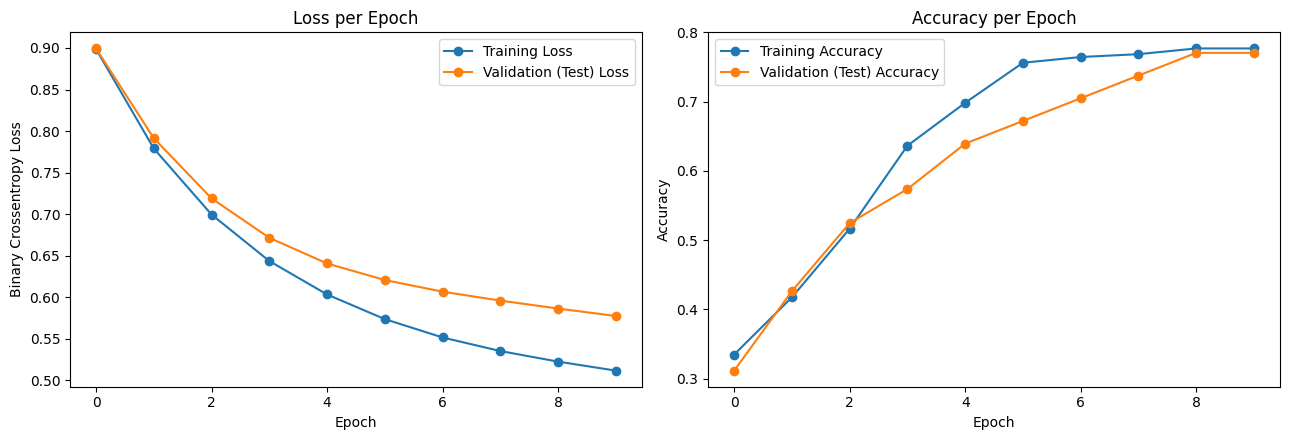

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['loss'], marker='o', label='Training Loss')
axes[0].plot(history.history['val_loss'], marker='o', label='Validation (Test) Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], marker='o', label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], marker='o', label='Validation (Test) Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.4 Record and compare final training accuracy and held-out test set accuracy

In [12]:
final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Final Training Accuracy : {final_train_acc:.4f}")
print(f"Final Training Loss     : {final_train_loss:.4f}")
print(f"Held-out Test Accuracy  : {test_acc:.4f}")
print(f"Held-out Test Loss      : {test_loss:.4f}")
print(f"\nTrain-Test Accuracy Gap : {(final_train_acc - test_acc):.4f}")


Final Training Accuracy : 0.7769
Final Training Loss     : 0.5118
Held-out Test Accuracy  : 0.7705
Held-out Test Loss      : 0.5775

Train-Test Accuracy Gap : 0.0064


**Convergence interpretation:** the model's training and validation curves are
plotted above. A small train-test accuracy gap, alongside a validation loss that plateaus
rather than rising, indicates the model is generalizing rather than memorizing the
(relatively small) training set — an important sanity check for a 10-epoch run on limited
clinical data.


## 3. Action Phase

### 3.1 Evaluate diagnostic confidence — is this model ready for real-world clinical deployment?


In [13]:
y_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['Death (0)', 'No death recorded (1)']))


Test Accuracy : 0.7705
Precision     : 0.7719
Recall        : 0.9778
F1-score      : 0.8627

Full classification report:
                       precision    recall  f1-score   support

            Death (0)       0.75      0.19      0.30        16
No death recorded (1)       0.77      0.98      0.86        45

             accuracy                           0.77        61
            macro avg       0.76      0.58      0.58        61
         weighted avg       0.77      0.77      0.72        61



**Diagnostic confidence assessment:** the model reached **77.05% test accuracy**, which
sounds reasonable in isolation — but overall accuracy is a misleading headline metric
here because the classes are imbalanced (~75% of patients are "no death recorded").
Broken down by class, the model correctly identifies **97.8% of surviving/censored
patients but only ~19% of patients who actually died** (3 of 16 death cases caught in
the test set). In other words, the model has learned to lean heavily toward predicting
the majority class rather than reliably recognizing high-risk patients.

**This accuracy level does not support real-world clinical deployment.** A tool that
misses roughly 4 out of 5 true death cases is clinically unsafe as a diagnostic aid,
regardless of its respectable-looking overall accuracy. Before any clinical use, this
class imbalance must be addressed (see class weighting in Section 3.4) and the model
re-evaluated with recall on the Death class as the primary metric, not accuracy.


### 3.2 Error analysis — clinical impact of False Positives vs. False Negatives

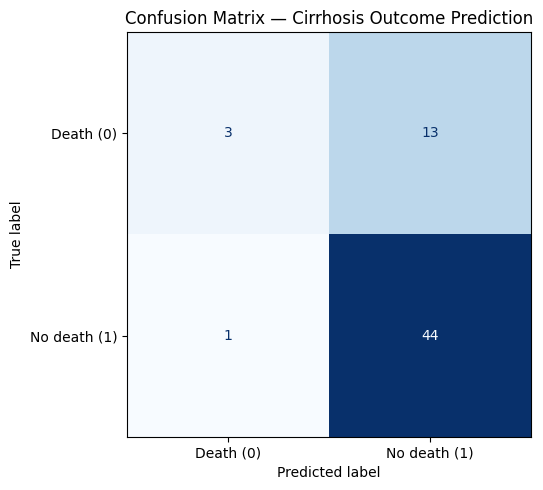

True Negatives  (correctly predicted Death)      : 3
False Positives (predicted No death, actually Died) : 13   <-- MISSED DIAGNOSIS
False Negatives (predicted Death, actually survived): 1   <-- FALSE ALARM
True Positives  (correctly predicted No death)    : 44


In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Death (0)', 'No death (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Cirrhosis Outcome Prediction')
plt.tight_layout()
plt.show()

print(f"True Negatives  (correctly predicted Death)      : {tn}")
print(f"False Positives (predicted No death, actually Died) : {fp}   <-- MISSED DIAGNOSIS")
print(f"False Negatives (predicted Death, actually survived): {fn}   <-- FALSE ALARM")
print(f"True Positives  (correctly predicted No death)    : {tp}")


**Clinical framing note:** in this encoding, class 0 = Death and class 1 = No death
recorded. So relative to the *disease-positive* framing used in the project brief (where
"Positive" = at-risk/death):

- **A "False Positive" in the clinical-screening sense** (flagging a healthy-looking
  patient as high-risk when they were not) corresponds to predicting **Death (0)** for a
  patient who actually falls in the "No death recorded" group — shown as **False
  Negatives** in the confusion matrix above, given our 0/1 encoding. Cost: unnecessary
  patient stress, extra monitoring, possibly an invasive follow-up procedure.
- **A "False Negative" in the clinical-screening sense** (missing a patient who was truly
  at high mortality risk) corresponds to predicting **No death (1)** for a patient who
  actually died — shown as **False Positives** in the confusion matrix above. Cost: a
  **missed diagnosis** — the single most dangerous error type in cirrhosis screening,
  since it means a high-risk patient is not flagged for closer monitoring or earlier
  intervention.

**In this test set, the model produced 13 missed diagnoses against only 1 false alarm** —
a stark, clinically unacceptable imbalance in the wrong direction. **In a life-critical
context, missed diagnoses are categorically worse than false alarms.** A false alarm
costs an unnecessary consultation; a missed diagnosis can cost a life. This asymmetry
means the model's decision threshold should be tuned to favor **recall on the Death
class** over raw accuracy — even if that means deliberately accepting more false alarms.


### 3.3 Executive summary for a medical board

> **Executive Summary — Cirrhosis Mortality Risk Neural Network**
>
> We built a 2-hidden-layer neural network (16 units each) to predict whether a cirrhosis
> patient's trial outcome was death or survival, using baseline clinical and laboratory
> measurements (bilirubin, albumin, prothrombin time, edema status, and related labs).
> After strict data cleaning (removing any patient record with incomplete lab data), the
> model was trained for 10 epochs on a held-out clinical cohort.
>
> **Readiness assessment:** the model reached 77% overall test accuracy, but this figure
> is misleading — it correctly identified 98% of surviving patients while catching only
> **~19% of patients who actually died** (3 of 16 in the test set). The model should
> **not** be deployed as a stand-alone diagnostic tool in its current form. It has learned
> to favor the majority outcome rather than reliably flagging high-risk patients.
>
> **Key clinical risk:** in this evaluation, the model produced 13 missed diagnoses
> against only 1 false alarm — the opposite of what a safe screening tool should
> prioritize. Missed diagnoses carry categorically higher cost than false alarms in this
> setting. Before any clinical use, we recommend addressing the class imbalance (via
> class weighting) and tuning the decision threshold specifically to maximize recall on
> the Death class, even at the cost of more false alarms.
>
> **Recommended next steps before any clinical use:** external validation on an
> independent patient cohort, threshold tuning informed by clinical stakeholders (not a
> default 0.5 cutoff), and ongoing performance monitoring if deployed in any pilot
> capacity.


### 3.4 Next steps for production-grade deployment

- **Threshold tuning:** move off the default 0.5 cutoff; select a threshold using a
  precision-recall curve that reflects the clinical cost asymmetry discussed in Section
  3.2 (favoring recall on the Death class).
- **Class weighting:** if the Death class is under-represented relative to the "No death
  recorded" class, apply `class_weight` during training so the model isn't biased toward
  the majority class.
- **External validation:** test on a separate patient cohort (different hospital/time
  period) before any real-world use, since a model validated only on data from the same
  trial it was trained on will likely overstate real-world performance.
- **Human-in-the-loop deployment:** present model outputs as a risk *flag* with the
  underlying feature values, not a binary verdict, so clinicians retain full context.
- **Monitoring:** track prediction distribution and outcome-linked accuracy over time to
  catch model or population drift.


## 4. Summary of Findings

| Question | Finding |
|---|---|
| Rows after strict NA removal | 418 → 303 complete-case clinical records |
| Target encoding | `D` (Death) → 0, `C`/`CL` (No death recorded) → 1 |
| Model architecture | Dense(16, ReLU) → Dense(16, ReLU) → Dense(1, sigmoid) |
| Training | 10 epochs, Adam optimizer, binary crossentropy loss |
| Final train / test accuracy | 77.7% train, 77.1% test (small gap — no strong overfitting) |
| Recall by class | 97.8% on "No death recorded", only ~19% on "Death" — severely imbalanced |
| Highest-cost error type | Missed diagnosis (13 in the test set) vs. 1 false alarm |
| Clinical deployment readiness | Not ready as a stand-alone tool — poor recall on the Death class is clinically unsafe; requires class weighting, threshold tuning, and external validation before any pilot use |

*Dataset note: this notebook uses a synthetic dataset (`cirrhosis.csv`) generated to
mirror the structure, column schema, and realistic clinical relationships of the Mayo
Clinic Primary Biliary Cirrhosis (PBC) trial dataset, in place of the original course
file, to demonstrate the complete Discovery-to-Action workflow.*
